## 4. EDOs de 1ª ordem: soluções analíticas com SymPy

### 4.1 Introdução

"Um modelo matemático frequentemente tem a forma de uma equação diferencial, isto é, uma equação que contém uma função desconhecida e algumas de suas derivadas. Isso não surpreende, porque em uma situação real normalmente notamos que mudanças ocorrem e queremos predizer o comportamento futuro com base na maneira como os valores presentes variam." ([Stewart et al., 2022](https://integrada.minhabiblioteca.com.br/reader/books/9786555584103/pageid/37)) 

A Figura 4.1 ilustra dos modelos matemáticos para o crescimento populacional $P(t)$ em que $P$ é o número de inivíduos e $t$ é o tempo.  O primeiro modelo baseia-se na hipótese de que uma população cresce a uma taxa proporcional ao seu tamanho (razoável para uma população em condições ideais, ou seja, meio ambiente ilimitado, nutrição adequada, ausência de predadores e imunidade a doenças). O segundo modelo assume que a taxa de crescimento populacional é proporcional tanto à população quanto à diferença entre a capacidade de suporte $M$ e a população. A equação desse modelo é chamada *equação diferencial logística*.

<img src="https://github.com/tiagoburiol/MatComp_III/blob/main/Notebook%2004%20-%20EDOs%20de%201%C2%AA%20ordem%2C%20solu%C3%A7%C3%B5es%20anal%C3%ADticas%20com%20SymPy/imagens/crescimento_populacional.png?raw=true" width="500"/>

Figura 4.1 - ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9786555584103/pageid/38)) Dois modelos matemáticos para o crescimento populacional.

As equações diferenciais são usadas para modelar sistemas em todos os campos da engenharia e da ciência, tais como o movimento de fluidos, o fluxo de corrente elétrica, a dissipação de calor, a propagação de ondas, etc ([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/26%5B%3Bvnd.vst.idref%3Dchapter01%5D!/4/12%5Bsec1-1%5D/3:29%5Bs%20B%2C%C3%A1si%5D)).

A ordem de uma equação diferencial é determinada pela mais alta ordem da derivada da função $y(x)$ presente na equação. As equações a seguir são exemplos de equações diferenciais ordinárias. Temos as seguintes notações usuais:

$$y'= \frac{dy}{dx}, \,\,\,  y''= \frac{d^2y}{dx^2}, \,\,\,... $$

Por exemplo:

$ \frac{dy}{dx} = 3x-1$ é uma EDO de ordem 1

$ y' = -xy$ é uma EDO de ordem 1

$ \frac{d^2y}{dx^2} = x^2-y+e^x$ é uma EDO de ordem 2 

$ y'' -4y' + 3y = x$ é uma EDO de ordem 2 

$ \frac{d^5y}{dx^5} + 3x\frac{dy}{dx}=2$ é uma EDO de ordem 5 


Resolver uma equação diferencial consiste em determinar uma função que satisfaça a equação. Em alguns casos, encontrar soluções exatas para certas equações diferenciais pode ser uma tarefa difícil ou até mesmo impossível. Nestes casos, a abordagem numérica é a alternativa para tornar essas equações úteis em projetos e estudo de fenômenos diversos. Métodos gráficos, como plotar um campo de direções, pode ser útil para avaliar o com portamento qualitativo das soluções de uma equação diferencial.

Por exemplo, é facil verificar que a solução geral da equação diferencial

$$
y^{\prime}=x^3
$$

é dada por

$$
y=\frac{x^4}{4}+C
$$

onde $C$ é uma constante qualquer.
Mas, em geral, resolver uma equação diferencial não é uma tarefa fácil. Não existe uma técnica sistemática que nos permita resolver todas as equações diferenciais. 

### 4.2 Campo de direções

"Muitos dos princípios, ou leis, que regem o comportamento do mundo físico são proposições, ou relações, envolvendo a taxa segundo a qual as coisas acontecem."([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/26%5B%3Bvnd.vst.idref%3Dchapter01%5D!/4/12%5Bsec1-1%5D/3:29%5Bs%20B%2C%C3%A1si%5D)) 

Em linguagem matemática, as relações são equações, e as taxas são derivadas. Em situações em que não é simples ou conveniente obter a solução explícita de uma EDO, é possível fazer deduções qualitativas sobre o comportamento das soluções a partir do desenho das taxas de variação (direções) em uma "grade" de pontos.

Veremos alguns exemplos a seguir.


**Exemplo 4.1:** ([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/26%5B%3Bvnd.vst.idref%3Dchapter01%5D!/4/16/3:168%5Blid%2Cos%5E%2C%5D))
 Considere um objeto em queda livre, na atmosfera, perto do nível do mar. 

A lei física que governa o movimento de objetos é a segunda lei de Newton, que diz que a massa do objeto multiplicada por sua aceleração é igual à força total atuando sobre o objeto, ou seja

$$F=m a$$

em que $m$ é a massa do objeto, $a$ é sua aceleração e $F$ é a força total agindo sobre o objeto. Como a aceleração é a taxa instantanea de variação da velocidade $v$ em relação ao tempo $t$, podemos escrever

$$
F=m \frac{d v}{d t}
$$


Agora vamos considerar que $F=mg-\gamma v$, em que $\gamma$ é a constante de resistência do ar. Então o modelo matemático (simplificado) que descreve esse movimento é dado pela EDO de 1ª ordem

$$
m \frac{d v}{d t}=m g-\gamma v
$$

Vamos supor que $m = 10$ kg e $\gamma = 2$ kg/s, então a equação acima pode ser reescrita como

$$
\frac{d v}{d t}=9,8-\frac{v}{5}
$$

Supondo agora que $v = 40$  m/s, então $dv/dt = 1,8$ m/s². 

Isso significa que o coeficiente angular (ou inclinação) da reta tangente ao gráfico de uma solução $v = v(t)$ tem valor $1,8$ em qualquer ponto no qual $v = 40$.  Procedendo da mesma maneira com outros valores de $v$, criamos um **campo de direções** ou **campo de inclinações**. O campo de direções nos permite fazer deduções qualitativas sobre o comportamento das soluções mesmo não tendo encontrado solução alguma.

Vamos agora construir o campo de direções da equação utilizando Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)

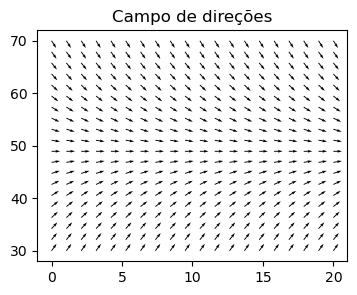

In [2]:
# campo de vetores
t = np.linspace(0,20, 20)
v = np.linspace(30, 70, 20)
tm, vm = np.meshgrid(t, v)
dv = 9.8-vm/5
dt = np.ones(dv.shape)

norm = np.sqrt(dt**2 + dv**2)

# plots
plt.title("Campo de direções")
plt.quiver(tm,vm,dt/norm,dv/norm, angles='xy')

plt.show()


A função constante $v(t) = 49$ é uma solução, pois substituindo $v(t) = 49$ na na equação, as expressões dos dois lados do sinal de igualdade são iguais a zero. Como essa solução não varia com o tempo, $v(t) = 49$ é chamada solução de equilíbrio. 

Observando o campo de direções, podemos chegar a conclusão de que todas as outras soluções (as quais dependem das condições iniciais do problema) parecem estar convergindo para a solução de equilíbrio quando $t$ aumenta. 

**Exemplo 4.2:** ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/26%5B%3Bvnd.vst.idref%3Dchapter01%5D!/4/158/17:54%5Brio%2C%20ma%5D))
A solução geral da equação $\frac{dv}{dt}=9,8-\frac{v}{5}$, apresentada no Exemplo 4.1, é dada por

$$v(t)=49+c e^{-t / 5}$$

em que a constante $c$ é arbitrária. Para determinar a constante $c$ precisamos de uma condição inicial, por exemplo $v(0)=0$, que fornece a solução particular $v(t)=49\left(1-e^{-t / 5}\right)$.

Vamos agora plotar as soluções para diversos valores de $c$, juntamente com o campo de direções, a curva vermelha corresponde a solução particular para o caso de $v(0)=0$. 

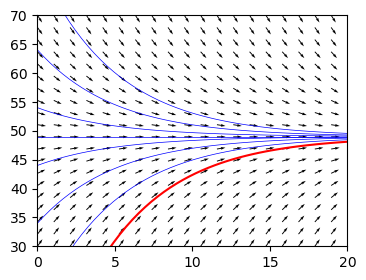

In [3]:
ti = np.linspace(0,20)
vi = lambda t: 49 + c*np.exp(-t/5)

for c in [-30,-15,-5,0,5,15,30]:
    plt.plot(ti, vi(ti), lw=0.5, color='b')

plt.plot(ti, 49*(1-np.exp(-ti/5)), color='r')
plt.quiver(tm,vm,dt/norm,dv/norm, angles='xy')
plt.xlim(0,20)
plt.ylim(30,70)
plt.show()

Para verificar que $v(t)=49+c e^{-t / 5}$ é uma solução da equação $\frac{d v}{d t}=9,8-\frac{v}{5}$ podemos usar o módulo de computação symbólica SymPy como é mostrado a abaixo

In [4]:
import sympy as sp

# definindo os símbolos e a função
t, c = sp.symbols('t, c')
v = 49 + c*sp.exp(-t/5)

In [5]:
#lado esquerdo da equação (obtendo dv/dt)
v.diff(t)

-c*exp(-t/5)/5

In [6]:
#lado direito da equação
9.8-v/5

-c*exp(-t/5)/5

In [7]:
# testando se o lado direito e o lado esquerdo são iguais
v.diff(t)==9.8-v/5

True

### 4.3. Solução geral e gráficos 

A seguir vamos ver como verificar se uma função é solução de uma EDO usando derivação com SymPy.

**Exemplo 4.3:** A equação diferencial $y' = -x y$ tem solução $ y = c \, e^{\frac{-x^2}{2}}$ com $c$ constante, pois 

$$ y' = c \, e^{\frac{-x^2}{2}}(-x) = -xy$$

ou seja, a função $y(x)$ satisfaz a equação. Vamos confirmar usando `sympy`.

In [8]:
# Define os símbolos e funções
x,c = sp.symbols('x,c')
y = c*sp.exp(-x**2/2)

# verificando se y é solução
sp.Eq(y.diff(x),-x*y)

True

Note que a função $ y(x) = c \, e^{\frac{-x^2}{2}}$ apresenta infinitas soluções da equação diferencial, pois, para cada valor diferente de $c$ temos uma função diferente que também satisfaz a equação, logo também é solução. Vamos agora plotar as soluções para diversos valores de $c$.

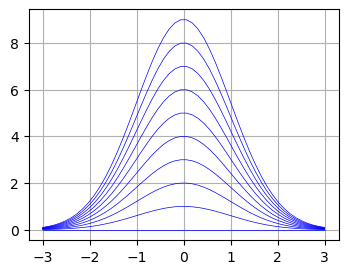

In [9]:
# Definindo a função usando a sintaxe "lambda" 
y = lambda x: np.exp((-x**2)/2) 

# Definindo um intervalo de x para o plot
x = np.linspace(-3,3)

for c in range(10):
    plt.plot(x, c*y(x), lw=0.5, color='blue')
    
plt.grid()
plt.show()

No exemplo acima, a solução geral da equação diferencial de primeira ordem foi dada e assim pudemos plotar as diferentes soluções para diferentes valores iniciais. No entanto, a maioria das equações diferenciais não pode ser resolvida explicitamente com funções elementares. Para esses casos sempre podemos aproximar soluções construindo o campo de direções. 

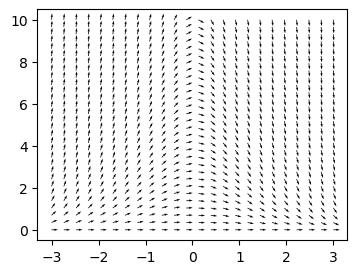

In [10]:
# campo de vetores
xm, ym = np.meshgrid(np.linspace(-3,3, 24), 
                     np.linspace(0, 10, 30))
dy = -xm*ym
dx = np.ones(dy.shape)
norm = np.sqrt(dx**2 + dy**2)
plt.quiver(xm,ym,dx/norm,dy/norm, angles='xy'),   
plt.show()

**Exemplo 4.4:** A equação diferencial $\frac{du}{dt} = t + 2$ tem solução obtida facilmente integrando ambos os lados da equação fazendo

$$ \int \frac{du}{dt} dt = \int (t+2)dt $$

$$ u(t) = \frac{t^2}{2}+2t+k$$

em que $k$ é a constante de integração. 

Se impomos uma condição, como por exemplo $u(0)= 8$, obtemos o valor $k=8$, que restringe a solução a uma única curva e não mais à uma família de curvas. Uma equação diferencial com condições iniciais como essa compõem o que chamamos de um *problema de valor inicial* (PVI).

Ou seja, o problema de valor inicial descrito acima pode ser enunciado como

$$ 
\begin{cases} 
\frac {du}{dt}= t+2\\ 
\\
u(0)=8
\end{cases}$$

Encontrando a solução particular com SymPy:

In [11]:
t = sp.symbols('t')
u = sp.Function('u')

eq = sp.Eq(u(t).diff(t), t + 2)

sol = sp.dsolve(eq, ics={u(0): 8})
display(sol)

Eq(u(t), t**2/2 + 2*t + 8)

Plotando o campo de direções junto com a solução particular do PVI ($k=8$):

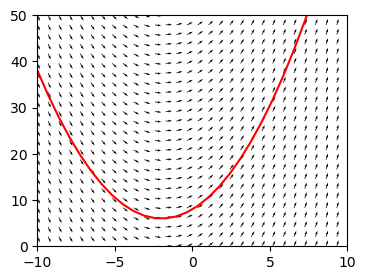

In [12]:
# campo de vetores
t = np.linspace(-10,10, 30)
u = np.linspace(0, 50, 25)
tm, um = np.meshgrid(t, u)
du = tm + 2
dt = np.ones_like(tm)

norm = np.sqrt(dt**2 + du**2)

# plots
plt.quiver(tm,um, dt/norm, du/norm, angles='xy')
plt.plot(t, (t**2/2)+2*t+8, 'r')
plt.xlim(-10,10)
plt.ylim(0,50)
plt.show()

### Atividade 4.1

1. Verifique que a função $y(t) = 3t + t^2$ é solução da equação diferencial $ty' - y = t^2$ usando `SymPy`.

2. Resolva os problemas de valor inicial a seguir e desenhe os gráficos das soluções para diversos valores de $y_0$. Observe as semelhanças e diferenças entre as soluções.

    a) $\dfrac{dy}{dx} = y-5$, $y(0)=y_0$

    b) $\dfrac{dy}{dx} = 2y-5$, $y(0)=y_0$

    c) $\dfrac{dy}{dx} = 2y-10$, $y(0)=y_0$

(Fonte: [Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841))

### 4.4 Métodos analíticos para resolver EDOs de 1ª ordem

Vamos agora ver três métodos analíticos clássicos: **fator integrante**, **variáveis separáveis** e **equações exatas**, sempre conferindo os resultados com `SymPy`.

#### 4.4.1 Fator integrante

Para utilizar o método do **fator integrante**, a EDO deve se apresentar da seguinte forma:

$$y'+p(t)y=g(t)$$

O método consiste em multiplicar ambos os lados da equação por $\mu(t)=e^{\int p(t)dt}$ e integrar, então chega-se à solução geral

$$y(t)=\frac{1}{\mu(t)}\int \mu(t)g(t)dt+c.$$

No entanto, nem sempre é possivel calcular a integral em termos de funções elementares. Quando for possível calcular, uma solução particular pode ser obtida calculando o valor da constante $c$ a partir de um valor inicial $y(t_0)=y_0$ dado.

**Exemplo 4.5:** ([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841/epubcfi/6/28%5B%3Bvnd.vst.idref%3Dchapter02%5D!/4/110/5:38%5B%C3%A7%C3%A3o%2C%20co%5D)) Resolva o problema de valor inicial $\quad t y^{\prime}+2 y=4 t^2$, $\quad y(1)=2$.

_Solução:_ Reescrevendo a equação como

$$
y^{\prime}+\frac{2}{t} y=4 t
$$

Calculando o fator integrante $\mu(t)= e^{\int \frac{2}{t} dt}=e^{2 \ln |t|}=t^2$ e multiplicando pela equação, obtemos

$$
t^2 y^{\prime}+2 t y=\left(t^2 y\right)^{\prime}=4 t^3
$$

$$
t^2 y=\int 4 t^3 d t=t^4+c
$$

$$
y=t^2+\frac{c}{t^2}, \quad t>0
$$

Fazendo $t=1$ e $y=2$ obtém-se que $c=1$, logo a solução do problema de valor inicial é

$$
y=t^2+\frac{1}{t^2},\quad  t>0
$$

Usando SymPy, podemos repetir os passos da resolução desse exemplo como é mostrado a seguir:

In [13]:
# Define os símbolos e funções
t, c1 = sp.symbols('t, c1')
y = sp.Function('y')(t)
dy = y.diff(t)
edo = sp.Eq(dy+2/t *y, 4*t)
display(edo)

Eq(Derivative(y(t), t) + 2*y(t)/t, 4*t)

In [14]:
# fator integrante
mu = sp.exp(sp.integrate(2/t))
display(mu)

t**2

In [15]:
# multiplicando o fator integrante
eq = sp.expand(sp.Eq(edo.lhs*mu, edo.rhs*mu))
display(eq)

Eq(t**2*Derivative(y(t), t) + 2*t*y(t), 4*t**3)

In [16]:
eq = sp.Eq(t**2*y, sp.integrate(4*t**3)+c1)
display(eq)

Eq(t**2*y(t), c1 + t**4)

In [17]:
sol = sp.solve(eq,y)[0]
display(sol)

(c1 + t**4)/t**2

In [18]:
eq = sp.Eq(sol.subs(t,1),2)
eq

Eq(c1 + 1, 2)

In [19]:
sp.solve(eq,c1)

[1]

Por outro lado, usando a função `dsolve` **obtemos a solução diretamente**:

In [20]:
sp.dsolve(edo)

Eq(y(t), (C1 + t**4)/t**2)

Fazendo o gráfico para alguns valores de $C_1$:

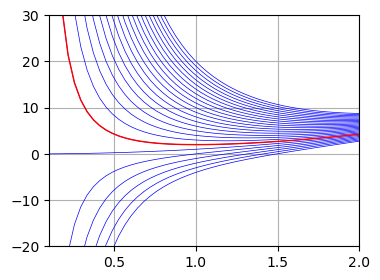

In [21]:
y = lambda t: c/t**2 + t**2
t = np.linspace(0.1,2)
for c in range(-5,20):
    plt.plot(t, y(t), lw=0.5, color='blue')

c = 1
plt.plot(t, y(t), lw=1, color='r')
plt.xlim(0.1, 2)
plt.ylim(-20,30)
plt.grid()
plt.show()

#### Atividade 4.2

1. Encontre a solução geral das equações a seguir usando o método do fator integrante e confira o resultado com `sp.dsolve`.

    a) $y'+xy=x$

    b) $y'+6y=e^x$

    c) $y'+3x^2y=\text{sen}(x)e^{-x^3}$

2. Resolva o problema de valor inicial
$$\begin{cases} 2y'+ty=2 \\ y(0)=1 \end{cases}$$

3. Para cada uma das equações a seguir: desenhe o campo de direções; com base nele, descreva o comportamento das soluções para valores grandes de $t$; e encontre a solução geral, usando-a para confirmar o comportamento de $y(t)$ quando $t \to \infty$.

    a) $y'+3y= t+e^{-2t}$

    b) $y'-2y = t^2e^{2t}$

    c) $y'+y =5\,\text{sen}(2t)$

([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841))

#### 4.4.2 Variáveis separáveis

Dizemos que uma EDO de 1ª ordem é de **variáveis separáveis** se puder ser escrita na forma

$$ y' = f(t) g(y)$$

nesse caso, escrevemos 

$$\frac{dy}{dt} = f(t) g(y)$$

ou 

$$\frac{1}{g(y)}dy = f(t)dt $$

e integramos o lado esquerdo em relação à $y$ e o lado direito em relação à $t$ para obter a solução, ou seja, fazemos

$$\int \frac{1}{g(y)}\,dy = \int f(x) \,dx + c $$

Vejamos um exemplo:

**Exemplo 4.6:** Seja a equação $y'=xy$, tem-se que $y=0$ é uma solução, para encontrar uma expressão para a solução geral, com $y \neq 0$ podemos usar o método de separação de variáveis fazendo

$$\int \frac{dy}{y} = \int x\,dx$$

$$\ln \, \lvert y\rvert = \frac{x^2}{2} + C$$

$$ \lvert y \rvert = e^{\frac{x^2}{2} + C} = e^{\frac{x^2}{2}} e^C = D e^{\frac{x^2}{2}}$$

Assim, para uma constante $D > 0$ a solução é
$$y = D e^{\frac{x^2}{2}}$$

In [22]:
x,y,C,D = sp.symbols('x,y,C, D')
sp.integrate(1/y, y)

log(y)

In [23]:
eq = sp.Eq(sp.integrate(1/y, y),sp.integrate(x, x)+C)
eq

Eq(log(y), C + x**2/2)

#### Atividade 4.3

1. Resolva as equações diferenciais separáveis a seguir.

    a) $y'=\dfrac{x^2}{y}$

    b) $y'+y^2\text{sen}(x)=0$

    c) $y'=\cos^2(x)\cos^2(2y)$

    d) $xy'=(1-y^2)^{1/2}$

2. Encontre a solução dos problemas de valor inicial a seguir, na forma explícita.

    a) $y'=(1-2x)y^2, \quad y(0)=-1/6$

    b) $y'=xy^3(1+x^2)^{-1/2}, \quad y(0)=1$

    c) $y'=(3x^2-e^x)/(2y-5), \quad y(0)=1$

    d) $\text{sen}(2x)\,dx+\cos(3y)\,dy=0, \quad y(\pi/2)=\pi/3$

([Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841))

In [24]:
sol = sp.solve(eq,y)
display(sol)

[exp(C + x**2/2)]

In [25]:
sol[0].subs(sp.exp(C),D)

D*exp(x**2/2)

#### 4.4.3 Equações exatas
As **equações diferenciais exatas** são aquelas que podem ser colocadas na forma

$$M(x,y)+N(x,y)y'=0$$

em que  $M_y(x,y) = N_x(x,y)$. O que significa que existe uma função $\psi (x, y)$ tal que $\psi_x=M$ e $\psi_y=N$.


Vejamos um exemplo.

**Exemplo 4.7:** Vamos resolver a equação 

$$2x+y^2+2xyy'=0 \text.$$


_Resolução:_ 

Temos que $M(x,y)=2x+y^2$ e $N(x,y)=2xy$. Integrando $\psi_x=M(x,y)$ em relação a $x$, obtemos 

$$\psi(x,y)=\int M(x,y) dx = 2x+y^2 dx = x^2+y^2x + h(y)$$.

Derivando $\psi(x,y)= x^2+y^2x + h(y)$ em relação a $y$ obtemos

$$ \frac{\partial \psi}{\partial y}= 2x+y^2 + h'(y)$$

Comparando $\psi_y$ com $N(x,y)$ conclui-se que $h'(y)=0$, portanto $h(y)=c$ (constante).

Assim, concluímos que a solução $\psi(x,y)=c$ da equação é dada 

$$2x+y^2=c$$

ou, ainda

$$ y(x) = \pm \sqrt{\frac{c}{x}-x}$$

In [26]:
t = sp.symbols('t')
y = sp.Function('y')(x)

expr = sp.Eq(2*x+y*y+2*x*y*y.diff(x),0)
expr

Eq(2*x*y(x)*Derivative(y(x), x) + 2*x + y(x)**2, 0)

In [27]:
sol = sp.dsolve(expr)
display(sol[0])
display(sol[1])

Eq(y(x), -sqrt(C1/x - x))

Eq(y(x), sqrt(C1/x - x))

#### Atividades finais

**1.** Resolva as equações a seguir usando o método mais adequado (fator integrante ou variáveis separáveis) e teste a solução obtida com `SymPy`.
    
a) $y'=\dfrac{x^2}{y}$

b) $y'+y^2\text{sen}(x)=0$

c) $y'=\cos^2(x)\cos^2(2y)$

d) $xy'=(1-y^2)^{1/2}$

e) $y'+xy=x$

f) $y'+6y=e^x$

g) $y'+3x^2y=\text{sen}(x)e^{-x^3}$

(Fonte: [Boyce e Diprima, 2024](https://integrada.minhabiblioteca.com.br/reader/books/9788521638841))

**Referências**

BOYCE, William E.; DIPRIMA, Richard C. Equações Diferenciais Elementares e Problemas de Valores de Contorno. Grupo GEN, 2024. E-book. ISBN 9788521638841. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9788521638841/. Acesso em: 28 ago. 2026.

STEWART, James; CLEGG, Daniel; WATSON, Saleem. Cálculo v.2. 6. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2022. E-book. ISBN 9786555584103. Disponível em: https://integrada.minhabiblioteca.com.br/#/books/9786555584103/. Acesso em: 28 ago. 2026.